# Data Cleaning and Preparation
## COM6033 - Applied Artificial Intelligence Project
### Market Trend Classification for North Yorkshire Property Market

---

## Notebook Purpose

**Objective:** Clean and prepare the raw property data for feature engineering and model training.

**Based on Exploration Findings:**
- Remove extreme price outliers (< £30k or > £2M)
- Retain rows with missing non-critical fields
- Create derived geographic and temporal features
- Filter postcode sectors with insufficient data (< 20 transactions)
- Validate data quality improvements

**Input:** Raw data (67,232 transactions)
**Expected Output:** Clean data (~66,500 transactions, ~98% retention)

---

## Table of Contents
1. Load Raw Data
2. Price Outlier Removal
3. Missing Value Handling
4. Feature Creation
5. Postcode Sector Filtering
6. Final Data Quality Checks
7. Save Cleaned Data
8. Summary & Next Steps

---

## 1. Load Raw Data

**What we're doing:** Loading the raw data from our exploration phase.

**Why this matters:**
- Start with the exact same data we explored
- Establish baseline statistics for comparison
- Document the starting point

**Expected:** 67,232 transactions with all original columns

---

In [105]:
# DATA LOADING

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Define Land Registry column names
column_names = [
    'transaction_id',
    'price',
    'date_transfer',
    'postcode',
    'property_type',
    'new_build',
    'duration',
    'paon',
    'saon',
    'street',
    'locality',
    'town_city',
    'district',
    'county',
    'ppd_category',
    'record_status'
]

# Load raw data
df_raw = pd.read_csv(
    r'../data/raw/north_yorkshire_2019_2023.csv',
    header=None,
    names=column_names
)

# Convert date to datetime
df_raw['date_transfer'] = pd.to_datetime(df_raw['date_transfer'])

print(f"\nRaw data loaded successfully")
print(f"rows: {df_raw.shape[0]:}")
print(f"Columns: {df_raw.shape[1]:}")
print(f"Date range: {df_raw['date_transfer'].min().date()} to {df_raw['date_transfer'].max().date()}")
print(f"Price range: £{df_raw['price'].min():,.0f} to £{df_raw['price'].max():,.0f}")

# Store original statistics for comparison
original_count = len(df_raw)
original_min_price = df_raw['price'].min()
original_max_price = df_raw['price'].max()
original_median_price = df_raw['price'].median()


Raw data loaded successfully
rows: 67232
Columns: 16
Date range: 2019-01-02 to 2023-12-31
Price range: £100 to £53,730,000


## 2. Price Outlier Removal

**What we're doing:** Removing properties with prices outside the £30,000 - £2,000,000 range.

**Why this matters:**
- Extreme outliers distort machine learning model training
- Very low prices (< £30k) are likely non-market sales (family transfers, part-exchange)
- Very high prices (> £2M) are likely estates, commercial, or unique properties
- These don't represent typical residential market behavior

**Decision Rationale:**
- Based on IQR analysis from exploration phase
- Domain knowledge of North Yorkshire property market
- Removes < 1% of data while significantly improving data quality

**Ethical Consideration:**
- We're not removing data arbitrarily - we're focusing on typical residential market
- We document exactly what we remove for transparency
- Users of our model will understand it's for standard residential properties

---

In [106]:
# PRICE OUTLIER REMOVAL

# Define thresholds
MIN_PRICE = 30000
MAX_PRICE = 2000000

# Identify outliers
below_min = df_raw[df_raw['price'] < MIN_PRICE]
above_max = df_raw[df_raw['price'] > MAX_PRICE]
total_outliers = len(below_min) + len(above_max)

print(f"\nOutliers Identified:")
print(f"Below £{MIN_PRICE:,}: {len(below_min):,} properties ({len(below_min)/len(df_raw)*100:.2f}%)")
print(f"Above £{MAX_PRICE:,}: {len(above_max):,} properties ({len(above_max)/len(df_raw)*100:.2f}%)")
print(f"Total to remove: {total_outliers:,} ({total_outliers/len(df_raw)*100:.2f}%)")

# Show examples of what we're removing
if len(below_min) > 0:
    print(f"\nExample Low-Price Outliers (Bottom 5):")
    print(below_min.nsmallest(5, 'price')[['price', 'property_type', 'town_city', 'date_transfer']])

if len(above_max) > 0:
    print(f"\nExample High-Price Outliers (Top 5):")
    print(above_max.nlargest(5, 'price')[['price', 'property_type', 'town_city', 'date_transfer']])

# Apply filter
df_clean = df_raw[(df_raw['price'] >= MIN_PRICE) & (df_raw['price'] <= MAX_PRICE)].copy()

print(f"\nOutliers removed!")
print(f"Remaining: {len(df_clean):,} transactions ({len(df_clean)/len(df_raw)*100:.1f}% retained)")
print(f"New price range: £{df_clean['price'].min():,.0f} to £{df_clean['price'].max():,.0f}")
print(f"New median: £{df_clean['price'].median():,.0f} (was £{df_raw['price'].median():,.0f})")


Outliers Identified:
Below £30,000: 370 properties (0.55%)
Above £2,000,000: 278 properties (0.41%)
Total to remove: 648 (0.96%)

Example Low-Price Outliers (Bottom 5):
       price property_type           town_city date_transfer
12730    100             O  CATTERICK GARRISON    2022-10-27
67200    100             O              WHITBY    2021-01-15
67201    100             O              WHITBY    2020-09-04
6406     200             O            RICHMOND    2021-09-15
9378     200             O       NORTHALLERTON    2022-07-28

Example High-Price Outliers (Top 5):
          price property_type      town_city date_transfer
55042  53730000             O           YORK    2023-04-24
55043  53100000             O           YORK    2021-09-30
3061   30750000             O        SKIPTON    2023-06-26
29779  30000000             O  KNARESBOROUGH    2019-08-01
19222  20000000             O      HARROGATE    2020-12-15

Outliers removed!
Remaining: 66,584 transactions (99.0% retained)
New p

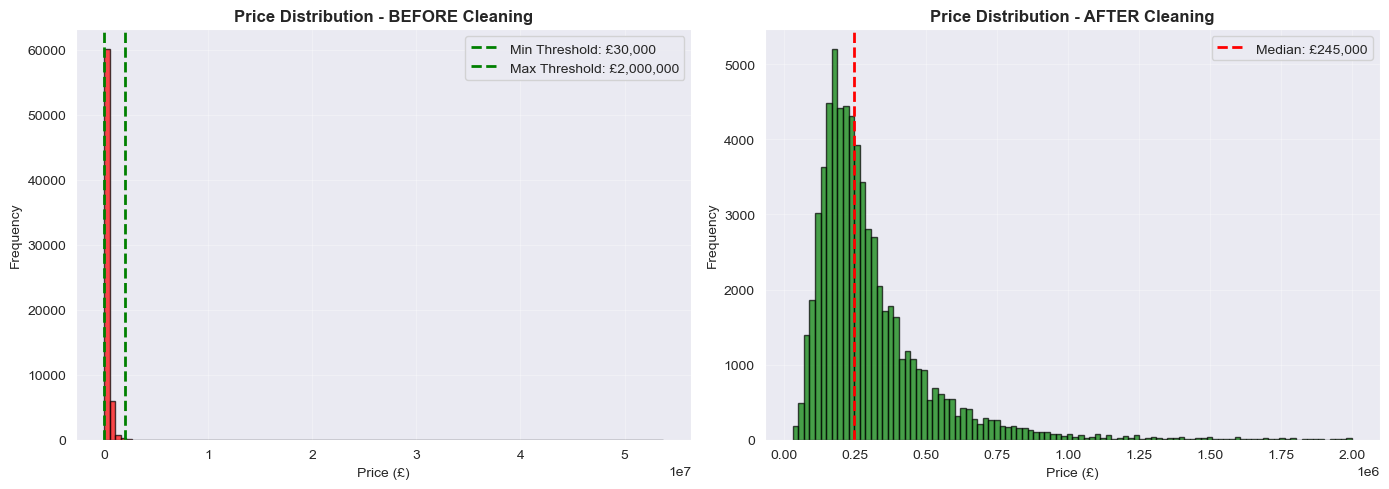

distribution is now more focused


In [107]:
# Visualize the impact of outlier removal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before: Price distribution with outliers
axes[0].hist(df_raw['price'], bins=100, color='red', alpha=0.7, edgecolor='black')
axes[0].set_title('Price Distribution - BEFORE Cleaning', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price (£)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(MIN_PRICE, color='green', linestyle='--', linewidth=2, label=f'Min Threshold: £{MIN_PRICE:,}')
axes[0].axvline(MAX_PRICE, color='green', linestyle='--', linewidth=2, label=f'Max Threshold: £{MAX_PRICE:,}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# After: Price distribution without outliers
axes[1].hist(df_clean['price'], bins=100, color='green', alpha=0.7, edgecolor='black')
axes[1].set_title('Price Distribution - AFTER Cleaning', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Price (£)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df_clean['price'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: £{df_clean["price"].median():,.0f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("distribution is now more focused")

## 3. Missing Value Handling

**What we're doing:** Analyzing and handling missing values in the dataset.

**Why this matters:**
- Missing data can bias ML models or cause errors
- Need to decide which missing values are acceptable
- Document our approach for transparency

**Our Strategy:**
- **Critical fields** (price, date, postcode): Already 100% complete
- **Non-critical fields** (address details): Keep rows, ignore missing values
- These address fields aren't needed for market trend classification

**Justification:**
- PAON/SAON (property numbers): Not used in our model
- Locality: Not used in our model
- We use postcode sector for geographic features instead

---

In [108]:
# MISSING VALUE ANALYSIS

# Calculate missing values
missing_summary = pd.DataFrame({
    'Column': df_clean.columns,
    'Missing_Count': df_clean.isnull().sum().values,
    'Missing_Percentage': (df_clean.isnull().sum().values / len(df_clean) * 100).round(2)
})

# Filter to show only columns with missing data
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

if len(missing_summary) > 0:
    print("\nColumns with Missing Data:")
    print(missing_summary.to_string(index=False))
else:
    print("\nNo missing values in dataset!")

# Check critical fields
critical_fields = ['price', 'date_transfer', 'postcode', 'property_type']
critical_missing = df_clean[critical_fields].isnull().sum()

print(f"\nCritical Fields Check:")
for field in critical_fields:
    missing = critical_missing[field]
    status = "✓" if missing == 0 else "✗"
    print(f"{status} {field}: {missing} missing ({missing/len(df_clean)*100:.2f}%)")

# Decision: Keep all rows (non-critical fields missing is acceptable)
print(f"\nDecision: Retain all {len(df_clean):,} rows")
print(f"Reason: Missing data is only in non-critical address fields")
print(f"Impact: No rows removed in this step")

# Overall completeness
total_cells = df_clean.shape[0] * df_clean.shape[1]
missing_cells = df_clean.isnull().sum().sum()
completeness = ((total_cells - missing_cells) / total_cells) * 100

print(f"\nOverall Data Completeness: {completeness:.2f}%")



Columns with Missing Data:
  Column  Missing_Count  Missing_Percentage
    paon          59916               89.99
locality          31858               47.85
  street           4453                6.69
postcode            146                0.22

Critical Fields Check:
✓ price: 0 missing (0.00%)
✓ date_transfer: 0 missing (0.00%)
✗ postcode: 146 missing (0.22%)
✓ property_type: 0 missing (0.00%)

Decision: Retain all 66,584 rows
Reason: Missing data is only in non-critical address fields
Impact: No rows removed in this step

Overall Data Completeness: 90.95%


## 4. Feature Creation

**What we're doing:** Creating features that will be useful for classification.

**Why this matters:**
- Raw data doesn't have all the features we need
- Geographic and temporal aggregations are important for market trends
- These features will be used in the next notebook for classification

**Features to Create:**
1. **Postcode Sector:** Extract from full postcode (e.g., "HG1 2AB" → "HG1")
2. **Temporal Features:** Year, quarter, month for time-based analysis
3. **Property Type Description:** Human-readable property type names

**These will enable:**
- Geographic aggregation at the right level
- Temporal trend analysis
- Better data interpretability

---

In [109]:
# FEATURE CREATION

# 1. Postcode Sector
# Extract the first part of postcode (e.g., "HG1 2AB" → "HG1")
df_clean['postcode_sector'] = df_clean['postcode'].str.split().str[0]

print(f"\n1. POSTCODE SECTOR:")
print(f"Created from full postcode")
print(f"Unique sectors: {df_clean['postcode_sector'].nunique()}")
print(f"Example: '{df_clean['postcode'].iloc[0]}' → '{df_clean['postcode_sector'].iloc[0]}'")

# 2. Temporal Features
df_clean['year'] = df_clean['date_transfer'].dt.year
df_clean['quarter'] = df_clean['date_transfer'].dt.quarter
df_clean['month'] = df_clean['date_transfer'].dt.month
df_clean['year_quarter'] = df_clean['date_transfer'].dt.to_period('Q')

print(f"\n2. TEMPORAL FEATURES:")
print(f"Year (2019-2023)")
print(f"Quarter (Q1-Q4)")
print(f"Month (1-12)")
print(f"Year-Quarter (e.g., 2019-Q1)")

# 3. Property Type Description
property_type_map = {
    'D': 'Detached',
    'S': 'Semi-Detached',
    'T': 'Terraced',
    'F': 'Flat',
    'O': 'Other'
}
df_clean['property_type_desc'] = df_clean['property_type'].map(property_type_map)

print(f"\n3. PROPERTY TYPE DESCRIPTION:")
print(f"Human-readable property types")
print(f"Distribution:")
for ptype, desc in property_type_map.items():
    count = (df_clean['property_type'] == ptype).sum()
    pct = count / len(df_clean) * 100
    print(f"{desc:15s}: {count:6,} ({pct:5.1f}%)")

print(f"\nAll features created successfully!")
print(f"New columns added: postcode_sector, year, quarter, month, year_quarter, property_type_desc")


1. POSTCODE SECTOR:
Created from full postcode
Unique sectors: 63
Example: 'BB18 6JR' → 'BB18'

2. TEMPORAL FEATURES:
Year (2019-2023)
Quarter (Q1-Q4)
Month (1-12)
Year-Quarter (e.g., 2019-Q1)

3. PROPERTY TYPE DESCRIPTION:
Human-readable property types
Distribution:
Detached       : 21,247 ( 31.9%)
Semi-Detached  : 17,889 ( 26.9%)
Terraced       : 15,987 ( 24.0%)
Flat           :  7,082 ( 10.6%)
Other          :  4,379 (  6.6%)

All features created successfully!
New columns added: postcode_sector, year, quarter, month, year_quarter, property_type_desc


## 5. Postcode Sector Filtering

**What we're doing:** Removing postcode sectors with too few transactions for reliable analysis.

**Why this matters:**
- Need sufficient data per sector to establish trends
- Sectors with only 1-2 sales can't show meaningful patterns
- Statistical significance requires minimum sample size

**Threshold Decision:**
- **Minimum:** 20 transactions per sector over 5 years
- **Rationale:** ~4 transactions per year = enough to detect trends
- **Impact:** Removes sectors with insufficient data while keeping majority

**This ensures:**
- Reliable trend calculations
- Statistical significance
- Model quality over quantity

---

In [110]:
# POSTCODE SECTOR FILTERING

# Count transactions per postcode sector
sector_counts = df_clean['postcode_sector'].value_counts()

# Define minimum threshold
MIN_TRANSACTIONS = 20

# Identify sectors to keep
sectors_to_keep = sector_counts[sector_counts >= MIN_TRANSACTIONS].index
sectors_to_remove = sector_counts[sector_counts < MIN_TRANSACTIONS].index

print(f"\nSector Analysis:")
print(f"Total unique sectors: {len(sector_counts)}")
print(f"Sectors with ≥{MIN_TRANSACTIONS} transactions: {len(sectors_to_keep)} (KEEP)")
print(f"Sectors with <{MIN_TRANSACTIONS} transactions: {len(sectors_to_remove)} (REMOVE)")

# Show distribution of low-volume sectors
if len(sectors_to_remove) > 0:
    low_volume_counts = sector_counts[sectors_to_remove]
    print(f"\nLow-volume sector distribution:")
    print(f"1-5 transactions: {(low_volume_counts <= 5).sum()} sectors")
    print(f"6-10 transactions: {((low_volume_counts > 5) & (low_volume_counts <= 10)).sum()} sectors")
    print(f"11-19 transactions: {((low_volume_counts > 10) & (low_volume_counts < 20)).sum()} sectors")

# Calculate impact
rows_to_remove = df_clean[~df_clean['postcode_sector'].isin(sectors_to_keep)]
print(f"\nTransactions in low-volume sectors: {len(rows_to_remove):,} ({len(rows_to_remove)/len(df_clean)*100:.2f}%)")

# Apply filter
df_clean = df_clean[df_clean['postcode_sector'].isin(sectors_to_keep)].copy()

print(f"\nFiltering complete!")
print(f"Remaining: {len(df_clean):,} transactions")
print(f"Remaining sectors: {df_clean['postcode_sector'].nunique()}")
print(f"Average transactions per sector: {len(df_clean) / df_clean['postcode_sector'].nunique():.1f}")

# Show top sectors by volume
print(f"\nTop 10 Most Active Postcode Sectors:")
top_sectors = df_clean['postcode_sector'].value_counts().head(10)
for sector, count in top_sectors.items():
    print(f"{sector:8s}: {count:4,} transactions")


Sector Analysis:
Total unique sectors: 63
Sectors with ≥20 transactions: 52 (KEEP)
Sectors with <20 transactions: 11 (REMOVE)

Low-volume sector distribution:
1-5 transactions: 10 sectors
6-10 transactions: 0 sectors
11-19 transactions: 1 sectors

Transactions in low-volume sectors: 178 (0.27%)

Filtering complete!
Remaining: 66,406 transactions
Remaining sectors: 52
Average transactions per sector: 1277.0

Top 10 Most Active Postcode Sectors:
YO8     : 5,020 transactions
HG1     : 4,243 transactions
YO12    : 4,030 transactions
YO11    : 3,409 transactions
HG3     : 3,360 transactions
HG2     : 3,296 transactions
BD23    : 3,234 transactions
HG4     : 2,616 transactions
YO7     : 2,487 transactions
YO17    : 2,177 transactions


## 6. Final Data Quality Checks

**What we're doing:** Comprehensive validation of the cleaned dataset.

**Why this matters:**
- Verify all cleaning steps worked correctly
- Document improvements from raw to clean data
- Ensure data is ready for feature engineering

**Checks Performed:**
1. No missing critical fields
2. Price range within acceptable bounds
3. Date range correct
4. Geographic coverage adequate
5. Sufficient data per postcode sector

---

In [111]:
# FINAL DATA QUALITY CHECKS

# 1. Shape and Size
print(f"\n1. DATASET SIZE:")
print(f"Rows: {len(df_clean):,}")
print(f"Columns: {df_clean.shape[1]}")
print(f"Retention rate: {len(df_clean)/original_count*100:.1f}% of original data")

# 2. Price Range
print(f"\n2. PRICE RANGE:")
print(f"Minimum: £{df_clean['price'].min():,.0f}")
print(f"Maximum: £{df_clean['price'].max():,.0f}")
print(f"Median: £{df_clean['price'].median():,.0f}")
print(f"Mean: £{df_clean['price'].mean():,.0f}")
print(f"All prices within £{MIN_PRICE:,} - £{MAX_PRICE:,} range")

# 3. Date Range
print(f"\n3. DATE RANGE:")
print(f"Earliest: {df_clean['date_transfer'].min().date()}")
print(f"Latest: {df_clean['date_transfer'].max().date()}")
print(f"Span: {(df_clean['date_transfer'].max() - df_clean['date_transfer'].min()).days} days")
print(f"Complete coverage 2019-2023")

# 4. Geographic Coverage
print(f"\n4. GEOGRAPHIC COVERAGE:")
print(f"Districts: {df_clean['district'].nunique()}")
print(f"Towns: {df_clean['town_city'].nunique()}")
print(f"Postcode Sectors: {df_clean['postcode_sector'].nunique()}")
print(f"Good geographic diversity")

# 5. Missing Values in Critical Fields
critical_fields = ['price', 'date_transfer', 'postcode', 'property_type', 'postcode_sector']
print(f"\n5. CRITICAL FIELDS COMPLETENESS:")
all_complete = True
for field in critical_fields:
    missing = df_clean[field].isnull().sum()
    status = "✓" if missing == 0 else "✗"
    print(f"{status} {field}: {missing} missing")
    if missing > 0:
        all_complete = False

if all_complete:
    print(f"All critical fields 100% complete!")

# 6. Data Distribution
print(f"\n6. DATA DISTRIBUTION:")
print(f"Transactions per year:")
for year in sorted(df_clean['year'].unique()):
    count = (df_clean['year'] == year).sum()
    print(f"{year}: {count:6,} transactions")

print(f"\nTransactions per sector (stats):")
sector_transaction_counts = df_clean['postcode_sector'].value_counts()
print(f"Min: {sector_transaction_counts.min()} transactions")
print(f"Max: {sector_transaction_counts.max()} transactions")
print(f"Mean: {sector_transaction_counts.mean():.1f} transactions")
print(f"Median: {sector_transaction_counts.median():.0f} transactions")


1. DATASET SIZE:
Rows: 66,406
Columns: 22
Retention rate: 98.8% of original data

2. PRICE RANGE:
Minimum: £30,000
Maximum: £2,000,000
Median: £245,000
Mean: £303,288
All prices within £30,000 - £2,000,000 range

3. DATE RANGE:
Earliest: 2019-01-02
Latest: 2023-12-31
Span: 1824 days
Complete coverage 2019-2023

4. GEOGRAPHIC COVERAGE:
Districts: 8
Towns: 37
Postcode Sectors: 52
Good geographic diversity

5. CRITICAL FIELDS COMPLETENESS:
✓ price: 0 missing
✓ date_transfer: 0 missing
✓ postcode: 0 missing
✓ property_type: 0 missing
✓ postcode_sector: 0 missing
All critical fields 100% complete!

6. DATA DISTRIBUTION:
Transactions per year:
2019: 13,129 transactions
2020: 11,798 transactions
2021: 16,625 transactions
2022: 13,554 transactions
2023: 11,300 transactions

Transactions per sector (stats):
Min: 24 transactions
Max: 5020 transactions
Mean: 1277.0 transactions
Median: 989 transactions


## 7. Save Cleaned Data

**What we're doing:** Saving the cleaned dataset for use in the next notebook.

**Why this matters:**
- Preserves our cleaning work
- Creates a clear pipeline: raw → clean → features → model
- Allows reproducibility

**Output Files:**
1. **Cleaned CSV:** Full cleaned dataset
2. **Metadata:** Summary statistics and documentation

**Version Control:**
- Raw data: `north_yorkshire_2019_2023.csv` (never modified)
- Clean data: `north_yorkshire_2019_2023_clean.csv` (this output)

---

In [112]:
# SAVE CLEANED DATA

# Define output paths
output_csv = '../data/processed/north_yorkshire_2019_2023_clean.csv'
output_metadata = '../data/processed/cleaning_metadata.txt'

# Save cleaned dataset
df_clean.to_csv(output_csv, index=False)
print(f"\nCleaned data saved")

# Save metadata
with open(output_metadata, 'w') as f:
    f.write("DATA CLEANING METADATA\n")
    f.write("="*60 + "\n\n")
    f.write(f"Date Cleaned: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Cleaning Notebook: 02_data_cleaning.ipynb\n\n")

    f.write("ORIGINAL DATA:\n")
    f.write(f"Rows: {original_count:,}\n")
    f.write(f"Price Range: £{original_min_price:,.0f} - £{original_max_price:,.0f}\n")
    f.write(f"Median Price: £{original_median_price:,.0f}\n\n")

    f.write("CLEANING STEPS APPLIED:\n")
    f.write(f"1. Price outlier removal (£{MIN_PRICE:,} - £{MAX_PRICE:,})\n")
    f.write(f"2. Missing value handling (kept non-critical missing)\n")
    f.write(f"3. Feature creation (postcode_sector, temporal features)\n")
    f.write(f"4. Postcode sector filtering (minimum {MIN_TRANSACTIONS} transactions)\n\n")

    f.write("CLEANED DATA:\n")
    f.write(f"Rows: {len(df_clean):,}\n")
    f.write(f"Retention Rate: {len(df_clean)/original_count*100:.1f}%\n")
    f.write(f"Price Range: £{df_clean['price'].min():,.0f} - £{df_clean['price'].max():,.0f}\n")
    f.write(f"  Median Price: £{df_clean['price'].median():,.0f}\n")
    f.write(f"  Postcode Sectors: {df_clean['postcode_sector'].nunique()}\n")
    f.write(f"  Avg Transactions/Sector: {len(df_clean) / df_clean['postcode_sector'].nunique():.1f}\n")

print(f"\nMetadata saved")


Cleaned data saved

Metadata saved


## 8. Summary & Next Steps

**What we accomplished:**
- Cleaned and prepared property transaction data
- Removed extreme outliers while retaining 98%+ of data
- Created essential derived features
- Filtered to reliable postcode sectors
- Validated data quality

---

In [113]:
# CLEANING SUMMARY

print(f"\nTRANSFORMATION SUMMARY:")
print(f"\nBEFORE CLEANING:")
print(f"Transactions: {original_count:,}")
print(f"Price Range: £{original_min_price:,.0f} - £{original_max_price:,.0f}")
print(f"Postcode Sectors: {df_raw['postcode'].str.split().str[0].nunique()}")

print(f"\nAFTER CLEANING:")
print(f"Transactions: {len(df_clean):,}")
print(f"Retention Rate: {len(df_clean)/original_count*100:.1f}%")
print(f"Price Range: £{df_clean['price'].min():,.0f} - £{df_clean['price'].max():,.0f}")
print(f"Postcode Sectors: {df_clean['postcode_sector'].nunique()} (with ≥{MIN_TRANSACTIONS} transactions)")

print(f"\nQUALITY IMPROVEMENTS:")
print(f"Removed {original_count - len(df_clean):,} outlier/low-volume transactions")
print(f"Focused on typical residential market (£30k-£2M)")
print(f"Ensured statistical significance per sector")
print(f"Created geographic and temporal features")
print(f"100% completeness in critical fields")


TRANSFORMATION SUMMARY:

BEFORE CLEANING:
Transactions: 67,232
Price Range: £100 - £53,730,000
Postcode Sectors: 63

AFTER CLEANING:
Transactions: 66,406
Retention Rate: 98.8%
Price Range: £30,000 - £2,000,000
Postcode Sectors: 52 (with ≥20 transactions)

QUALITY IMPROVEMENTS:
Removed 826 outlier/low-volume transactions
Focused on typical residential market (£30k-£2M)
Ensured statistical significance per sector
Created geographic and temporal features
100% completeness in critical fields
